In [1]:
library(Seurat)
library(Trex)
library(reticulate)
library(keras)
library(dplyr)
library(ggalluvial)
library(tidyr)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


The keras package is deprecated. Use the keras3 package instead.


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2



In [2]:
so <- readRDS('pep_rich_cluster.rds')
so

An object of class Seurat 
18129 features across 114208 samples within 1 assay 
Active assay: RNA (18129 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

# Clean up TCR data for TREX

In [3]:
library(stringr)

In [4]:
meta <- so@meta.data %>%
  mutate(
    TRAV = str_extract(CTgene, "TRAV[^*]*"),
    TRAJ = str_extract(CTgene, "TRAJ[^*]*"),
    TRAC = str_extract(CTgene, "TRAC[^*]*"),
    TRBV = str_extract(CTgene, "TRBV[^*]*"),
    TRBJ = str_extract(CTgene, "TRBJ[^*]*"),
    TRBC = str_extract(CTgene, "TRBC[^*]*")
  )
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,old.ident,RNA_snn_res.0.5,RNA_snn_res.0.7,RNA_snn_res.0.6,TRAV,TRAJ,TRAC,TRBV,TRBJ,TRBC
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
af336a467ebf11f0b8e5ee35decf83ac,SeuratProject,6421,3367,af336a467ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,Proliferating T cell,EXP-01618-PC,authorial_crazed_bunny,af336a467ebf11f0b8e5ee35decf83ac,⋯,15,2,1,2,TRAV13-1,TRAJ45,NA,NA,NA,NA
af336c587ebf11f0b8e5ee35decf83ac,SeuratProject,4009,2366,af336c587ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,only_lacquer_antelope,af336c587ebf11f0b8e5ee35decf83ac,⋯,5,3,7,3,TRAV8-3,TRAJ7,TRAC,TRBV5-8,TRBJ2-3,TRBC2
af336d7a7ebf11f0b8e5ee35decf83ac,SeuratProject,4557,2680,af336d7a7ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,Proliferating T cell,EXP-01618-PC,antebellum_grave_reindeer,af336d7a7ebf11f0b8e5ee35decf83ac,⋯,15,4,5,4,TRAV8-3,TRAJ17,TRAC,TRBV19,TRBJ2-3,TRBC2
af337c347ebf11f0b8e5ee35decf83ac,SeuratProject,4678,2674,af337c347ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,seaworthy_insipid_heron,af337c347ebf11f0b8e5ee35decf83ac,⋯,5,3,7,3,TRAV4,TRAJ40,TRAC,TRBV19,TRBJ1-3,TRBC1
af337f0e7ebf11f0b8e5ee35decf83ac,SeuratProject,2687,1822,af337f0e7ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,GZMK+ CD27+ EM CD8 T cell,EXP-01618-PC,aquarial_colloquial_terrapin,af337f0e7ebf11f0b8e5ee35decf83ac,⋯,8,0,0,1,NA,NA,NA,TRBV19,TRBJ2-3,TRBC2
af3381167ebf11f0b8e5ee35decf83ac,SeuratProject,3355,2106,af3381167ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,moistful_buoyant_lcont,af3381167ebf11f0b8e5ee35decf83ac,⋯,29,5,4,6,TRAV1-2,TRAJ33,TRAC,TRBV9,TRBJ2-3,TRBC2


In [5]:
so$CTgene_archive <- so$CTgene

In [6]:
so$CTgene <- paste0(meta$TRAV,'.',meta$TRAJ,'.',meta$TRAC,'_',meta$TRBV,'.',meta$TRBJ,'.',meta$TRBC)

In [7]:
so$CTaa_TRA <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 1)
so$CTaa_TRB <- stringr::str_split_i(string = so$CTaa, pattern = '_', i = 2)

In [8]:
so$CDR3a <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 1)
so$CTaa_TRA_2 <- stringr::str_split_i(string = so$CTaa_TRA, pattern = ';', i = 2)
so$CDR3b <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 1)
so$CTaa_TRB_2 <- stringr::str_split_i(string = so$CTaa_TRB, pattern = ';', i = 2)

In [9]:
so$CTaa_archive <- so$CTaa

In [10]:
so$CTaa <- paste(so$CDR3a,so$CDR3b,sep='_')

In [11]:
table(so$sample_id)


FIX10434-016 FIX10434-017 FIX10434-018 FIX10434-022 FIX10434-023 FIX10434-024 
        6972         8085         5478          617         2935         2306 
FIX10434-030 FIX10434-035 FIX10435-016 FIX10435-017 FIX10435-018 FIX10435-022 
        2733         2914        16837        17803        17365         5414 
FIX10435-023 FIX10435-024 FIX10435-028 FIX10435-034 
        6711         7737         6037         4264 

# Annotate Exact Match

In [12]:
so <- annotateDB(so, chains = "TRA", edit.distance = 0)

In [13]:
so <- annotateDB(so, chains = "TRB", edit.distance = 0)

In [14]:
exact_match_meta <- so@meta.data

In [15]:
# saveRDS(exact_match_meta, 'exact_match_meta.rds')

In [16]:
# exact_match_meta <- readRDS('exact_match_meta.rds')

In [17]:
table(is.na(so$CDR3a) == is.na(so$CDR3b))


  TRUE 
114208 

In [18]:
meta <- so@meta.data %>%
    filter(!is.na(CDR3a))
nrow(meta)

[1] 106800

In [19]:
table(is.na(meta$TRA_Epitope.species))


FALSE  TRUE 
36305 70495 

In [20]:
meta <- meta %>%
    mutate(CMV_TRA = case_when(
        is.na(meta$TRA_Epitope.species) ~ 'No Database Match',
        grepl('CMV', meta$TRA_Epitope.species) ~ 'Exact CMV',
        TRUE ~ 'Other'
        ))

In [21]:
meta <- meta %>%
    mutate(CMV_TRB = case_when(
        is.na(meta$TRB_Epitope.species) ~ 'No Database Match',
        grepl('CMV', meta$TRB_Epitope.species) ~ 'Exact CMV',
        TRUE ~ 'Other'
        ))

In [22]:
table(meta$CMV_TRA)
table(meta$CMV_TRB)


        Exact CMV No Database Match             Other 
            32752             70495              3553 


        Exact CMV No Database Match             Other 
            10526             95260              1014 

In [23]:
meta <- meta %>%
    mutate(CMV_combined = if_else(
        CMV_TRA == 'Exact CMV' | CMV_TRB == 'Exact CMV', 'Exact CMV', 'NA'))

In [24]:
table(meta$CMV_combined)


Exact CMV        NA 
    35945     70855 

In [25]:
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,AIFI_PBMC.Flex_L1,AIFI_PBMC.Flex_L2,AIFI_PBMC.Flex_L3,batch_id,cell_name,cell_uuid,⋯,TRA_Database,TRB_Epitope.target,TRB_Epitope.sequence,TRB_Epitope.species,TRB_Tissue,TRB_Cell.type,TRB_Database,CMV_TRA,CMV_TRB,CMV_combined
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
af336a467ebf11f0b8e5ee35decf83ac,SeuratProject,6421,3367,af336a467ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,Proliferating T cell,EXP-01618-PC,authorial_crazed_bunny,af336a467ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,NA,NA,NA,NA,No Database Match,No Database Match,NA
af336c587ebf11f0b8e5ee35decf83ac,SeuratProject,4009,2366,af336c587ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,only_lacquer_antelope,af336c587ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,NA,NA,NA,NA,No Database Match,No Database Match,NA
af336d7a7ebf11f0b8e5ee35decf83ac,SeuratProject,4557,2680,af336d7a7ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,Proliferating T cell,EXP-01618-PC,antebellum_grave_reindeer,af336d7a7ebf11f0b8e5ee35decf83ac,⋯,TBAdb;VDJdb,NA,NA,NA,NA,NA,NA,Exact CMV,No Database Match,Exact CMV
af337c347ebf11f0b8e5ee35decf83ac,SeuratProject,4678,2674,af337c347ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,seaworthy_insipid_heron,af337c347ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,NA,NA,NA,NA,No Database Match,No Database Match,NA
af337f0e7ebf11f0b8e5ee35decf83ac,SeuratProject,2687,1822,af337f0e7ebf11f0b8e5ee35decf83ac,T cell,Memory CD8 T cell,GZMK+ CD27+ EM CD8 T cell,EXP-01618-PC,aquarial_colloquial_terrapin,af337f0e7ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,NA,NA,NA,NA,No Database Match,No Database Match,NA
af3381167ebf11f0b8e5ee35decf83ac,SeuratProject,3355,2106,af3381167ebf11f0b8e5ee35decf83ac,T cell,Proliferating T cell,Proliferating T cell,EXP-01618-PC,moistful_buoyant_lcont,af3381167ebf11f0b8e5ee35decf83ac,⋯,NA,NA,NA,NA,NA,NA,NA,No Database Match,No Database Match,NA


In [26]:
new_meta <- so@meta.data %>%
    left_join(meta, by = 'barcodes')

In [27]:
table(so$barcodes == new_meta$barcodes)


  TRUE 
114208 

In [28]:
so$CMV_combined <- new_meta$CMV_combined

In [29]:
table(so$CMV_combined)


Exact CMV        NA 
    35945     70855 

In [50]:
df <- so %>%
    FetchData(vars = c('umap_1','umap_2','Stemness','CMV_combined'))

In [51]:
df$Stemness <- tidyr::replace_na(df$Stemness, 'Standard')
df$CMV_combined <- tidyr::replace_na(df$CMV_combined, 'NA')
df$Stemness <- factor(df$Stemness, levels = c('Standard','DMSO','TWS-119','UK5099'))

In [52]:
library(ggnewscale)

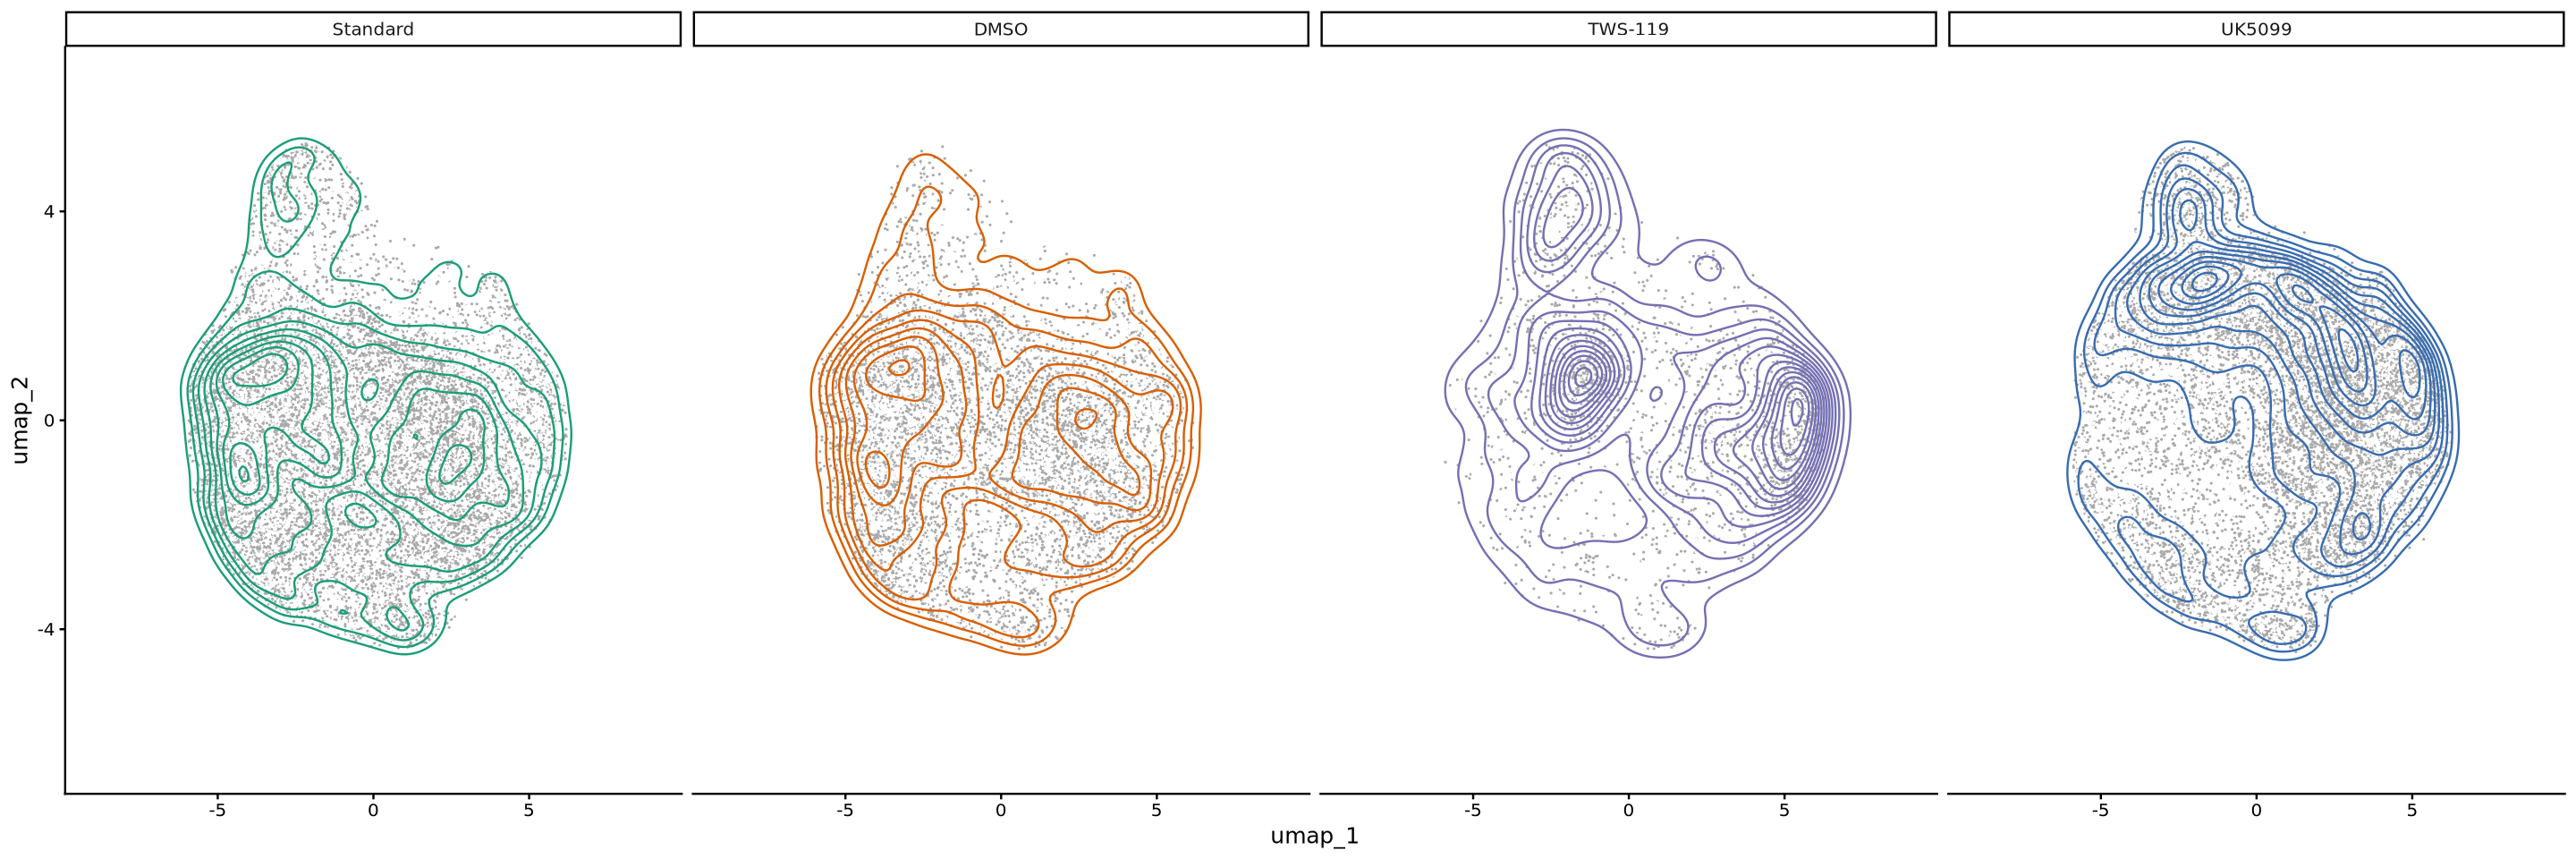

In [59]:
options(repr.plot.width = 24, repr.plot.height = 8)
ggplot(df,aes(x=umap_1, y=umap_2,color=CMV_combined)) + 
    geom_point(size=0.001, alpha=1) +
    xlim(-9,9) + ylim(-6.5,6.5) +
    scale_color_manual(values = c('darkgrey','transparent')) +
    new_scale_color() + 
    geom_density_2d(data = df, n=200, bins=15,
                     aes(x=umap_1,y=umap_2,color=Stemness), inherit.aes = F) +
    scale_color_manual(values = c('#1b9e77','#d95f02','#7570b3','#386cb0')) +
    # geom_text(data = cluster_centroids, aes(x=umap_1,y=umap_2,label=`seurat_clusters`),
    #           inherit.aes = F, size=6, fontface='bold', color='black') +
    theme_classic(base_size=15) + theme(legend.position = 'none') + facet_grid(cols = vars(Stemness))

In [60]:
# Open the PDF graphics device
pdf("plots/Fig2g_UMAPs_by_Treatment_plus_CMV.pdf", width = 24, height = 8) # You can specify width and height in inches

# Create your plot
ggplot(df,aes(x=umap_1, y=umap_2,color=CMV_combined)) + 
    geom_point(size=0.001, alpha=1) +
    xlim(-9,9) + ylim(-6.5,6.5) +
    scale_color_manual(values = c('darkgrey','transparent')) +
    new_scale_color() + 
    geom_density_2d(data = df, n=200, bins=15,
                     aes(x=umap_1,y=umap_2,color=Stemness), inherit.aes = F) +
    scale_color_manual(values = c('#1b9e77','#d95f02','#7570b3','#386cb0')) +
    # geom_text(data = cluster_centroids, aes(x=umap_1,y=umap_2,label=`seurat_clusters`),
    #           inherit.aes = F, size=6, fontface='bold', color='black') +
    theme_classic(base_size=15) + theme(legend.position = 'none') + facet_grid(cols = vars(Stemness))

# Close the graphics device to save the plot
dev.off()

agg_record_232510953 
                   2